# Ablation Row 3 — + Multi-scale pyramid (inference only)

| | Value |
|---|---|
| Features | full (same as row 2) |
| PCA | 4677 components (same as row 2) |
| Scales | **(0.75, 1.0, 1.5)** + cross-scale NMS |
| HNM | off |
| Threshold | `cfg.detection_threshold = 1.5` (default) |

Delta vs row 2: turn on the image pyramid. **No retraining** — loads
`microglia-artifacts-row2/`'s `svm_clf` / `scaler` / `pca` and runs multi-scale
detection on the test set. Same model, same patches, only the inference-time
sweep changes.

This isolates the pyramid contribution from any classifier-level confound.

## 1  Imports + Config + load row 2 model

In [1]:
import os
import joblib
import numpy as np
import matplotlib.image as mpimg

from pipeline import (
    Config,
    extract_raw_features, fit_pipeline,
    tune_svm, train_svm, evaluate_classifier,
    process_image, multi_scale_detect, non_max_suppression,
    load_gt_boxes, evaluate_detections, plot_gt_vs_pred,
    save_hard_negatives, tune_detection_threshold,
    ensure_test_patches, patch_level_test_eval, detection_level_test_eval,
    extract_features, list_images,
)

%matplotlib inline

In [2]:
# Inference-only: load the row 2 model and override scale_factors at the cfg
# level. Artifact paths still point at row 2 so we don't accidentally write here.
cfg = Config(
    artifact_dir='./microglia-artifacts-row2',
    feature_mode='full',
    scale_factors=(0.75, 1.0, 1.5),
    pca_n_components=4677,
    detection_threshold=1.5,
)
print(cfg)

svm_clf = joblib.load(cfg.svm_clf_path)
scaler  = joblib.load(cfg.scaler_path)
pca     = joblib.load(cfg.pca_path)
print(f"Loaded model from {cfg.artifact_dir}/")

Config(image_rois_csv='../Image_ROIs.csv', source_images='../Source_images', test_dir='../test_images', microglia_folder='./Processed_training_images/Train/Microglia', noise_folder='./Processed_training_images/Train/Noise', microglia_val_folder='./Processed_training_images/Validate/Microglia', noise_val_folder='./Processed_training_images/Validate/Noise', microglia_test_folder='./Processed_training_images/Test/Microglia', noise_test_folder='./Processed_training_images/Test/Noise', hnm_folder='./Processed_training_images/HardNegatives', artifact_dir='./microglia-artifacts-row2', features_cache='./microglia-artifacts-row2/features_cache.npz', svm_clf_path='./microglia-artifacts-row2/svm_clf.pkl', scaler_path='./microglia-artifacts-row2/scaler.pkl', pca_path='./microglia-artifacts-row2/pca.pkl', val_paths_cache='./microglia-artifacts-row2/val_paths.txt', hnm_train_final='./microglia-artifacts-row2/hnm_train_final.npz', image_size=2048, window_size=64, feature_mode='full', scale_factors=(0

Loaded model from ./microglia-artifacts-row2/


## 2  Test evaluation (no retraining)

── Patch-level test (unchanged from row 2) ──


  [test microglia] 245/245 (100%) — 245 feature vectors extracted


  [test noise] 1922/1922 (100%) — 1922 feature vectors extracted


[test] Accuracy  : 0.6530
[test] Precision : 0.2457
[test] Recall    : 1.0000
[test] F1-Score  : 0.3945

── Detection-level test (multi-scale, t=1.50) ──
Running detection on 2 test images at scales (0.75, 1.0, 1.5), threshold=1.50

── 13_s46 ──
  scale=0.75 (1536×1536px)  

/home/ec2-user/lx-svm-venv/lib/python3.13/site-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


...

     76% 

     86% 

     95% 

100%
  → 4828 candidates at this scale
  Total candidates : 7476


  After NMS        : 1791
  Detection time: 258.5s
  GT=123  Pred=1791  TP=71  FP=1720  FN=52  P=0.040  R=0.577


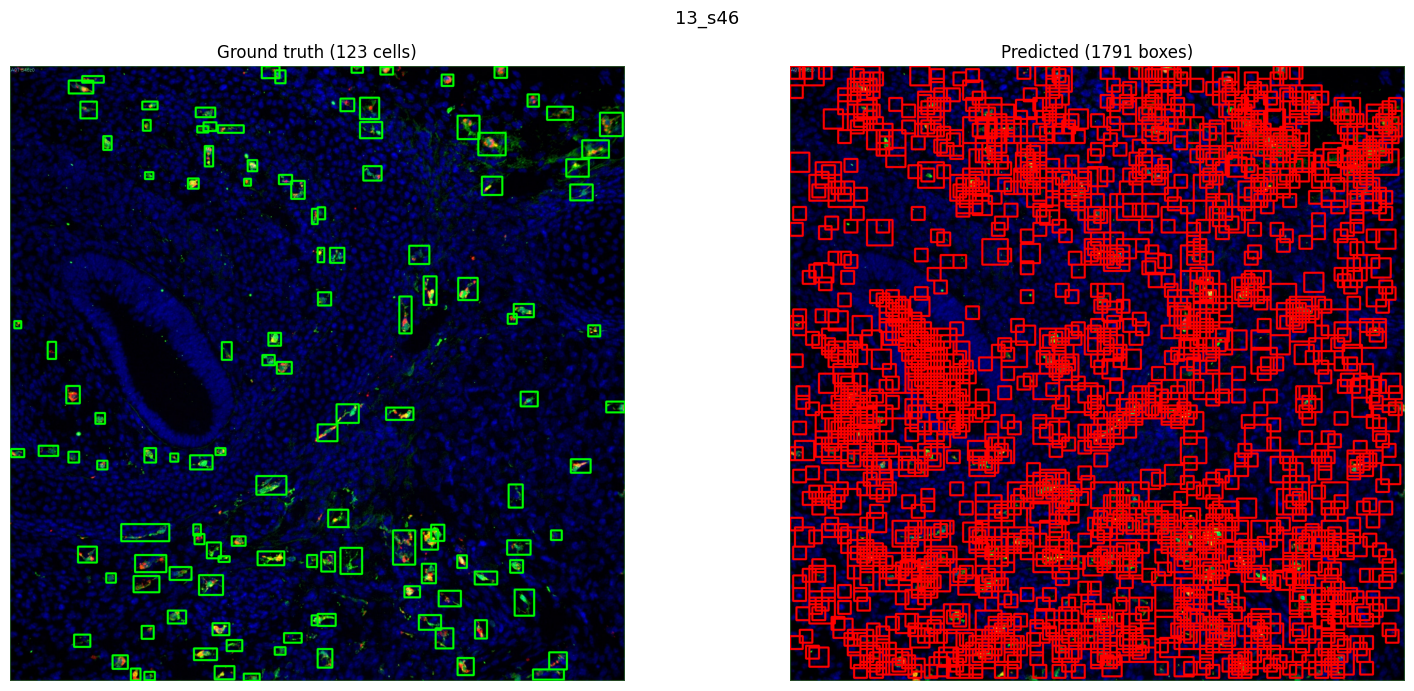


── 14_s47 ──
  scale=0.75 (1536×1536px)  

/home/ec2-user/lx-svm-venv/lib/python3.13/site-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


      0% 

      9% 

     19% 

...

     76% 

     86% 

     95% 

100%
  → 6146 candidates at this scale
  Total candidates : 9270


  After NMS        : 2155
  Detection time: 278.6s
  GT=122  Pred=2155  TP=85  FP=2070  FN=37  P=0.039  R=0.697


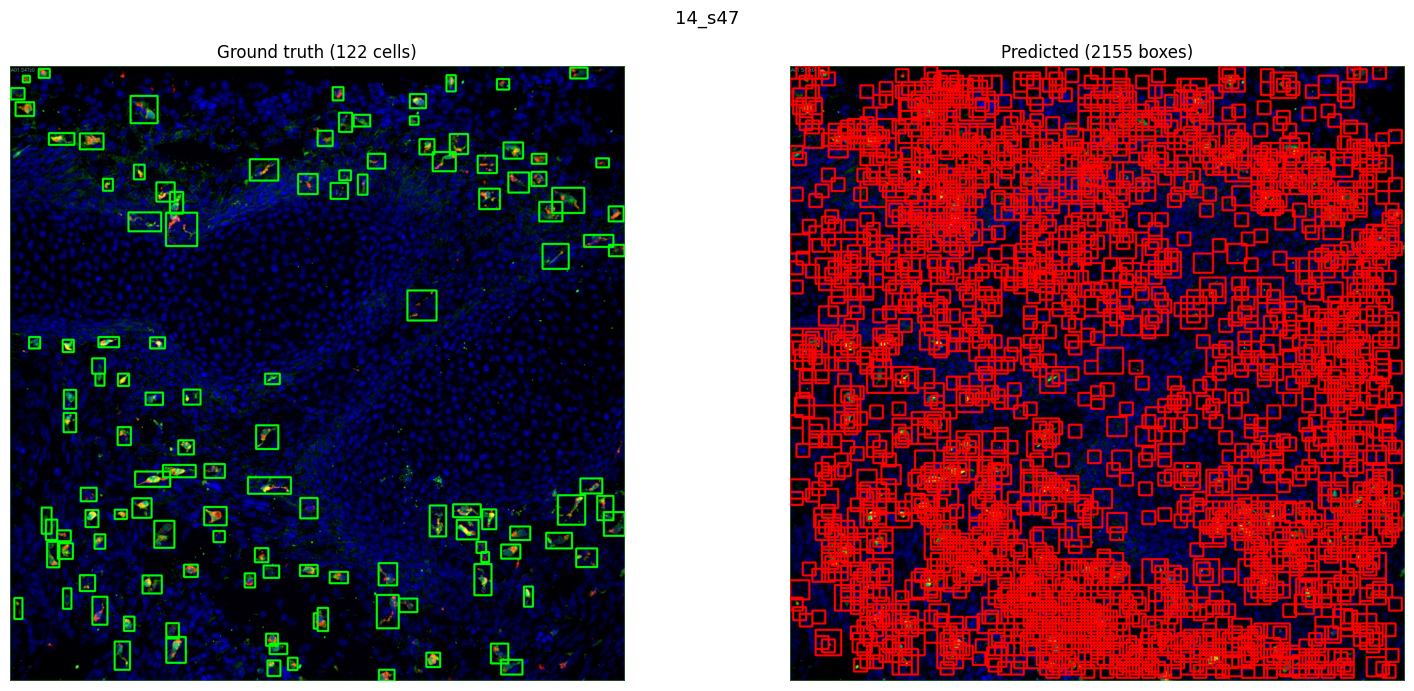


== AGGREGATE  TP=156  FP=3790  FN=89
   Precision=0.040  Recall=0.637  F1=0.074


In [3]:
ensure_test_patches(cfg)

print("── Patch-level test (unchanged from row 2) ──")
patch_level_test_eval(svm_clf, scaler, pca, cfg)

print("\n── Detection-level test (multi-scale, t=%.2f) ──" % cfg.detection_threshold)
row3_metrics = detection_level_test_eval(svm_clf, scaler, pca, cfg, show_plots=True)